# Models and Mapping

This tutorial (adapted from the original [SimPEG docs](https://docs.simpeg.xyz/v0.24.0/content/user-guide/tutorials/01-models_mapping/plot_1_tensor_models.html#sphx-glr-content-user-guide-tutorials-01-models-mapping-plot-1-tensor-models-py)) shows how to **define models** and **map them onto meshes** using SimPEG's `maps` module. 

<div style="text-align: center;">
  <img src="../images/simpeg/meshes_simpeg.png" alt="Meshes" width="800"/>
</div>
<div style="height: 28px;"></div>

| Author                             | Contact                             |
| :---------------------------------- | :---------------------------------- |
| [Polyanna Rowe](https://github.com/polyye) | [polyannar@mirageoscience.com](mailto:polyannar@mirageoscience.com) |

## Models vs. Maps 

**Model (`m`) = parameters you invert for.**  
- It’s *not necessarily* “one value per mesh cell.”  
- It **can be**:
  - Cell-wise values on **active (subsurface) cells** only, or
  - A **small set of parameters** (e.g., block center/size/contrast), or
  - Transformed quantities (e.g., **log** of conductivity).
- The **length of `m`** is whatever your parameterization needs (often `#active cells`, not `#all cells`).

**Map (`𝓜`) = how `m` becomes mesh-ready values.**  
- A **mapping** converts model-space into the vector space used by the simulation (i.e., a value for the relevant mesh cells).  
- Maps can:
  - **Transform** parameters (e.g., `ExpMap` to go from log to linear),
  - **Assemble** parametric models onto cells,
  - **Inject** active-cell values into the **full mesh** and **fill air** (e.g., `InjectActiveCells`),
  - Or simply pass values through (`IdentityMap`) if `m` is already what the simulation needs.

**Together:**  
$\underbrace{\mathbf{u}}_{\text{mesh values}} \;=\; \underbrace{\mathcal{M}}_{\text{map}}\; \underbrace{\mathbf{m}}_{\text{model}}$

- `u` is the **mesh-aligned vector** passed to the forward simulation.
- `m` is the **invertible parameter vector** (often smaller and air-free).
- `𝓜` applies any needed **transforms + placement** so the simulation sees the right thing.

**Why this separation?**  
- It lets you **change parameterizations** (cell-based, parametric, log-space, etc.) without changing the physics code.  
- In inversion, you update `m`; the map `𝓜` always turns it into the proper mesh values for predicting data and for plotting.




## Building a Tensor Mesh

We’ll build a **3D tensor mesh**, then map different kinds of **models** onto it.

In this notebook we will:

- Create a **tensor mesh** with a uniform core plus **padding** with an increasing cell size.
- Use **surface topography** to flag **active (subsurface) cells** for the simulation (air is excluded from the model and filled at plot/sim time via mapping).
- Map models to the mesh with `SimPEG` **maps**:
  - `InjectActiveCells`: expand an active-cells model to the full mesh (fills air with a constant).
  - **Combo maps** (e.g., `ExpMap`, `ReciprocalMap`) to a chain of simple transforms at once.
  - **Wires** to split/assemble multi-property models (e.g., density + susceptibility).
- Add simple **geologic structures** (blocks, dykes, spheres) and demonstrate both **parametric** and **cell-based** parameterizations in one workflow.


### Import Modules

In [1]:
from discretize import TensorMesh
from discretize.utils import active_from_xyz
from simpeg.utils import mkvc, model_builder
from simpeg import maps
import numpy as np
import matplotlib.pyplot as plt

# sphinx_gallery_thumbnail_number = 3

### Building an empty Tensor mesh from a centered coordinate system at origin [0, 0, 0]

We’ll use a **3D tensor mesh** shared by all examples: a uniform **core** with cell size `dh` in $[X, Y, Z]$, surrounded by **geometric padding** that coarsens away from the core. This keeps high resolution where it matters and reduces cost at the edges.

**Settings we use**
- Core cell size: `dh = 5 m`
- Core cells per axis: `20`
- Padding per side: `5` cells
- Padding growth: `×1.3` (outward from the core)

**About the `origin` / `x0` string (`'0'`, `'C'`, `'N'`)**
- You can pass a 3-character string to position the **zero coordinate** along each axis:  
  - `'0'`: zero is at the **first node** (minimum)  
  - `'C'`: zero is at the **center** of the mesh  
  - `'N'`: zero is at the **last node** (maximum)
- Examples:  
  - `"CCC"` → mesh **centered** about $(0,0,0)$  
  - `"0CC"` → $x=0$ at the **min x** edge; $y,z$ centered  
  - `"NN0"` → $x=0$ at **max x**, $y=0$ at **max y**, $z=0$ at **min z**

In [2]:
# Creating a function to facilitate mesh creation
def make_tensor_mesh(dh: float = 5.0,
                      n_core: int = 20,
                      n_pad: int = 5,
                      pad_rate: float = 1.3,
                      origin: str = "CCC") -> TensorMesh:
    """
    Create a centered 3D tensor mesh with a uniform core and geometric padding.

    Parameters
    ----------
    dh : float
        Core cell size (m).
    n_core : int
        Number of core cells per axis.
    n_pad : int
        Number of padding cells per side.
    pad_rate : float
        Geometric growth factor for padding (>1).
    origin : str
        Discretize origin code; "CCC" centers the mesh.

    Returns
    -------
    TensorMesh
        The constructed tensor mesh.
    """
    core = (dh, n_core)
    pad_neg = (dh, n_pad, -pad_rate)  # grow outward in -axis
    pad_pos = (dh, n_pad,  pad_rate)  # grow outward in +axis

    hx = [pad_neg, core, pad_pos]
    hy = [pad_neg, core, pad_pos]
    hz = [pad_neg, core, pad_pos]
    
    # Create the mesh with the specified origin
    return TensorMesh([hx, hy, hz], origin)

# Apply the function to create the mesh and store it to the variable `mesh`
mesh = make_tensor_mesh()

print(mesh)


  TensorMesh: 27,000 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x     30       -108.78        108.78      5.00     18.56    1.30
   y     30       -108.78        108.78      5.00     18.56    1.30
   z     30       -108.78        108.78      5.00     18.56    1.30




### Building an empty Tensor mesh from a core bounding box

You can use this helper pattern when you know the **exact 3D box** your mesh’s **uniform core** should cover, with **geometric padding** around it.

- **When to use:** whenever you need a **precise core footprint** (AOI/target volume) with consistent resolution and efficient padding.

**Example (call pattern):**
```python
mesh = tensor_from_core_bbox(
    xmin, xmax, ymin, ymax, zmin, zmax,
    dh=5.0, npad=5, pad_rate=1.3
)


In [3]:
# Creating a function to facilitate mesh creation (with coordinates from bounding box instead)
def tensor_from_core_bbox(
    xmin, xmax, ymin, ymax, zmin, zmax,
    dh=5.0,              # core cell size (uniform)
    npad=6,              # padding cells per side
    pad_rate=1.3         # geometric growth factor outward
):
    """
    Create a  3D tensor mesh with a uniform core from a bounding box and geometric padding.
    
    Parameters
    ----------
    xmin, xmax, ymin, ymax, zmin, zmax : float
        Bounding box coordinates defining the mesh extent. 
    dh : float
        Core cell size (m).    
    n_pad : int
        Number of padding cells per side.
    pad_rate : float
        Geometric growth factor for padding (>1).

    Returns
    -------
    TensorMesh
        The constructed tensor mesh.
    """
    
    # number of core cells along each axis (ceil so we cover the full extent)
    nx = int(np.ceil((xmax - xmin) / dh))
    ny = int(np.ceil((ymax - ymin) / dh))
    nz = int(np.ceil((zmax - zmin) / dh))

    # widths: (width, n, factor) -> [left padding | core | right padding]
    hx = [(dh, npad, -pad_rate), (dh, nx), (dh, npad, pad_rate)]
    hy = [(dh, npad, -pad_rate), (dh, ny), (dh, npad, pad_rate)]
    hz = [(dh, npad, -pad_rate), (dh, nz), (dh, npad, pad_rate)]

    # temporary mesh at origin to compute padding lengths
    tmp = TensorMesh([hx, hy, hz])  # origin at [0,0,0]

    # total "left" padding lengths on each axis
    Lpx = tmp.h[0][:npad].sum()
    Lpy = tmp.h[1][:npad].sum()
    Lpz = tmp.h[2][:npad].sum()

    # set origin so the core starts exactly at [xmin, ymin, zmin]
    x0 = np.r_[xmin - Lpx, ymin - Lpy, zmin - Lpz]

    return TensorMesh([hx, hy, hz], origin=x0)

# Example: replicate previous mesh creation (dh=5, 20 core cells per axis, 5 pads, rate=1.3)
dh = 5.0 # core cell size
n_core = 20 # number of core cells per axis
half_extent = (n_core * dh) / 2.0  # 50 m # half the extent of the core (20x5)/2

# Apply the function to create the mesh and store it to the variable `mesh`
mesh = tensor_from_core_bbox(
    xmin=-half_extent, xmax=half_extent,
    ymin=-half_extent, ymax=half_extent,
    zmin=-half_extent, zmax=half_extent,
    dh=dh, npad=5, pad_rate=1.3
)
print(mesh)


  TensorMesh: 27,000 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x     30       -108.78        108.78      5.00     18.56    1.30
   y     30       -108.78        108.78      5.00     18.56    1.30
   z     30       -108.78        108.78      5.00     18.56    1.30




> 💡 **Note:**  
> You can also size a mesh **directly from survey points** using `mesh_builder_xyz`, which wraps the XYZ coordinates (with optional padding and core depth). This is handy when you want the mesh to follow your data bounds without hand-coding limits:
> ```python
> discretize.utils.mesh_builder_xyz(
>    xyz, h, padding_distance=None, base_mesh=None, depth_core=None,
>    expansion_factor=1.3, mesh_type='tensor', tree_diagonal_balance=None
>)
> ```
> 
> - *xyz*: survey locations (N×3)   
> - *h*: base cell size (scalar or [hx, hy, hz])   
> - *padding_distance*: padding on each side (scalar or per-axis)  
> - *depth_core*: minimum core thickness below surface
> - *mesh_type*: 'tensor' or 'tree' (octree)
>
> This will come on handy in our full unconstrained and joint inversion examples.

### Create a Half-space model with topography at $z = 0$

We build a **half-space** where all cells **below** the surface ($z<0$) take a constant value and **air** cells are zero.

Key steps:
- Find **active cells**: `ind_active = (z < 0)`.
- Define an **InjectActiveCells** mapping so the model is stored only on active cells, while air is filled with a fixed value when plotting/simulating.
- Create the model vector (length = number of active cells) required by `SimPEG` to run the forward simulation (i.e. the physics) and plot a $Y$-slice.

This pattern mirrors inversion workflows where the model is defined only in the subsurface.

In [4]:
# Define Parameters
halfspace_value = 100.0   # value assigned to subsurface cells (z < 0), Resistivity, arbitrary units
air_value = 0.0           # value assigned to air cells (z >= 0)

# Identify the active (subsurface) cells in our mesh: z of cell centers < 0
ind_active = mesh.gridCC[:, 2] < 0.0   # Boolean mask where z < 0 (subsurface), with gridCC being the cell center coordinates

# Map: active-cell model -> full mesh (fills air cells with air_value)
model_map = maps.InjectActiveCells(mesh, ind_active, air_value)

# Create the model vector from ACTIVE cells only
# np.full creates an array with shape (N,) where N is the number of active cells, 
# and fills it with halfspace_value, with dtype=float
model = np.full(ind_active.sum(), halfspace_value, dtype=float)

### Plot the Mesh for the Half-Space model

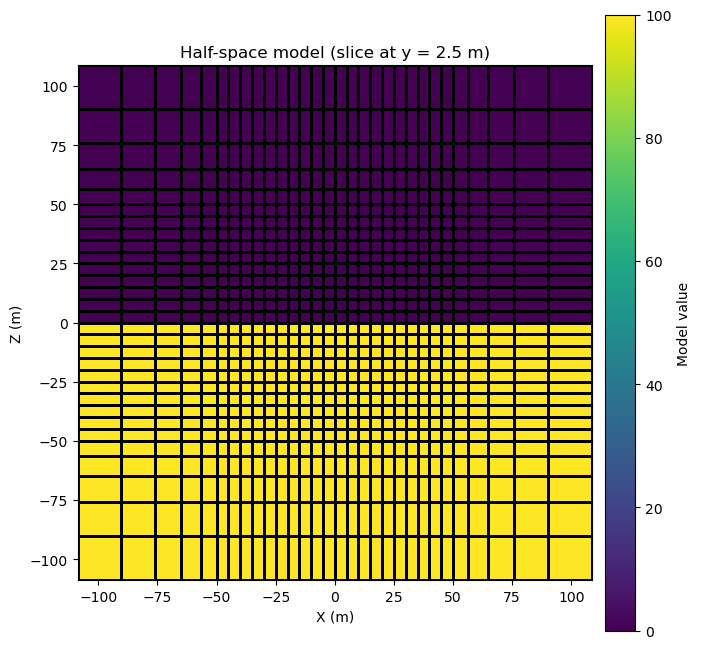

In [5]:
# Plot a Y-oriented slice through the center of the mesh
ind_slice = mesh.shape_cells[1] // 2  # middle index along Y (2nd axis)

fig, ax = plt.subplots(figsize=(8, 8))

# .plot_slice expects a FULL-mesh model; use model_map * model to expand model to full mesh
im = mesh.plot_slice(
    model_map * model,           # expand to full mesh for plotting
    normal="Y",                  # slice normal to Y
    ind=ind_slice,               # which Y-slice to show
    ax=ax,
    grid=True,                   # draw cell grid
    pcolor_opts={
        "cmap": plt.cm.viridis,  # colormap
        # lock color scale so air is the min and half-space the max
        "vmin": air_value,
        "vmax": halfspace_value,
    },
)

# Aesthetics
ax.set_title(f"Half-space model (slice at y = {mesh.cell_centers_y[ind_slice]:.1f} m)")
ax.set_xlabel("X (m)")
ax.set_ylabel("Z (m)")
ax.set_aspect("equal")  # keep X and Z to scale

# Colorbar
plt.colorbar(im[0], ax=ax, orientation="vertical", pad=0.02, label="Model value")

plt.show()

### Create a model with topography, block, and vertical dyke

Here, we create a model with:
- A **smooth topographic surface** at $z(x,y) = -3 \exp\left(\frac{x^{2}+y^{2}}{75^{2}}\right) + 40$
- A **background half-space**
- A **vertical dyke** striking along **Y** (bounded in **X**)
- A **rectangular block** at shallow depth

We first mark **active cells** (below topography) and use `InjectActiveCells` to **map a model** defined only on the subsurface (1D vector) to the **full 3D mesh** (air filled with `air_value`).



In [6]:
# Define model values, in this case resistivity (arbitrary units)
background_value = 100.0
dyke_value = 40.0
block_value = 70.0
air_value = 0.0

# Set up topography as a (N, 3) array
xx, yy = np.meshgrid(mesh.nodes_x, mesh.nodes_y, indexing="xy") # making a grid of X and Y coordinates from our mesh nodes
zz = -3.0 * np.exp((xx**2 + yy**2) / 75.0**2) + 40.0   # smooth hill
topo = np.c_[xx.ravel(), yy.ravel(), zz.ravel()] # combine X, Y, Z into a single array of shape (N, 3) with N being the number of nodes in the mesh

# Identify active cells in the mesh 
# This flags all cells whose centers lie below the topography
ind_active = active_from_xyz(mesh, topo) 

# Now choose how to map the model to mesh
# InjectActiveCells maps the model defined on active cells to the full mesh, filling air cells with air_value
model_map = maps.InjectActiveCells(mesh, ind_active, air_value)

# Create a model based on active cells only
# np.full creates an array with shape (N,) where N is the number of active cells, 
# and fills it with background_value, with dtype=float
model = np.full(ind_active.sum(), background_value, dtype=float) 

# vertical dyke (strikes along Y): limited in X, extends in Z
cc = mesh.gridCC[ind_active]  # cell centers for active cells
ind_dyke = (cc[:, 0] > 20.0) & (cc[:, 0] < 40.0) # We select all active cells with X coordinate between 20 and 40 m.
model[ind_dyke] = dyke_value # assigns a dyke value of 40 for these cells

# rectangular block in (X,Y,Z)
ind_block = (
    (cc[:, 0] > -40.0) & (cc[:, 0] < -10.0) & # get cell indices for X coordinate between -40 and -10
    (cc[:, 1] > -30.0) & (cc[:, 1] < 30.0)  & #                      Y coordinate between -30 and 30
    (cc[:, 2] > -40.0) & (cc[:, 2] < 0.0) #                          Z coordinate between -40 and 0. 
)
model[ind_block] = block_value # assigns a block value of 70 for these cells

### Plot the Mesh for the Topo + block + dyke model

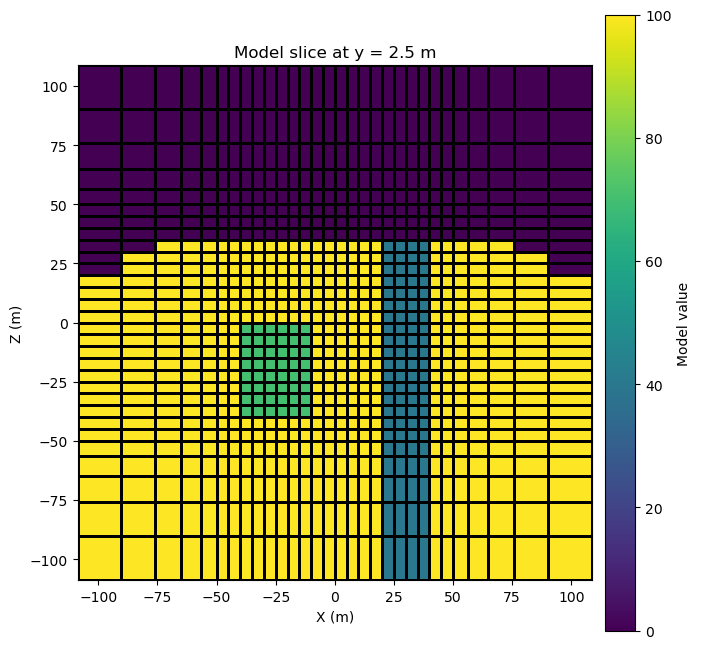

In [7]:
# Plot a central Y-slice
ind_slice = mesh.shape_cells[1] // 2  # middle index in Y
fig, ax = plt.subplots(figsize=(8, 8))

im = mesh.plot_slice(
    model_map * model,           # expand to full mesh for plotting
    normal="Y",                  # slice normal to Y
    ind=ind_slice,               # which Y-slice to show
    ax=ax,
    grid=True,
    pcolor_opts={
        "cmap": plt.cm.viridis,
        "vmin": air_value,
        "vmax": background_value
    },
)

ax.set_title(f"Model slice at y = {mesh.cell_centers_y[ind_slice]:.1f} m")
ax.set_xlabel("X (m)")
ax.set_ylabel("Z (m)")
ax.set_aspect("equal")
plt.colorbar(im[0], ax=ax, orientation="vertical", pad=0.02, label="Model value")
plt.show()

### Combo Maps

A **combo map** chains various `map` functions to turn your model `m` into the values you want **on the mesh**.

In this example, the model `m` stores **log-conductivity** (i.e., $m=\ln\sigma$) **only on active (subsurface) cells**, but we want to **plot resistivity** on the **full mesh**. So we:

1) **Exponentiate:** $\sigma = \exp(m)$  
2) **Invert to resistivity:** $\rho = 1/\sigma$ 
3) **Inject to full mesh:** fill air cells with a constant (leave them unchanged)  
  
> **Order matters (right-to-left):**  
> In SimPEG, `A * B * C` runs **`C` first**, then **`B`**, then **`A`**.  
> Thus `active_map * reciprocal_map * exponential_map` means:
> $
> \text{active\_map}\Big(\ \text{reciprocal\_map}\big(\ \text{exp\_map}(m)\ \big)\ \Big)
> $


In [8]:
# Log-conductivity values for each unit (our model parameters)
# At the end, we will plot resistivity (1/σ)
background_value = np.log(1.0 / 100.0) # Resistivity of 100
dyke_value       = np.log(1.0 /  40.0) # Resistivity of 40
block_value      = np.log(1.0 /  70.0) # Resistivity of 70

# Topography as (N, 3) points has already been defined above

# Identify active cells in the mesh + defining how to map from model to full mesh
ind_active = active_from_xyz(mesh, topo) # This flags all cells whose centers lie below the topography
active_map = maps.InjectActiveCells(mesh, ind_active, air_value)

# Create a log-conductivity model based on active cells only
# np.full creates an array with shape (N,) where N is the number of active cells, 
# and fills it with background_value, with dtype=float
model = np.full(ind_active.sum(), background_value, dtype=float)

# Dyke: x in (20, 40)
ind_dyke = (mesh.gridCC[ind_active, 0] > 20.0) & (mesh.gridCC[ind_active, 0] < 40.0)
model[ind_dyke] = dyke_value

# Block: x in (-40, -10), y in (-30, 30), z in (-40, 0)
ind_block = (
    (mesh.gridCC[ind_active, 0] > -40.0) & (mesh.gridCC[ind_active, 0] < -10.0) &
    (mesh.gridCC[ind_active, 1] > -30.0) & (mesh.gridCC[ind_active, 1] <  30.0) &
    (mesh.gridCC[ind_active, 2] > -40.0) & (mesh.gridCC[ind_active, 2] <   0.0)
)
model[ind_block] = block_value

# Compose the mapping: logσ  -> σ -> ρ -> inject to full mesh ---
exponential_map = maps.ExpMap()         # exp(m) -> conductivity
reciprocal_map  = maps.ReciprocalMap()  # 1/x   -> resistivity
model_map       = active_map * reciprocal_map * exponential_map

### Plot resistivity from the Log(conductivity) model

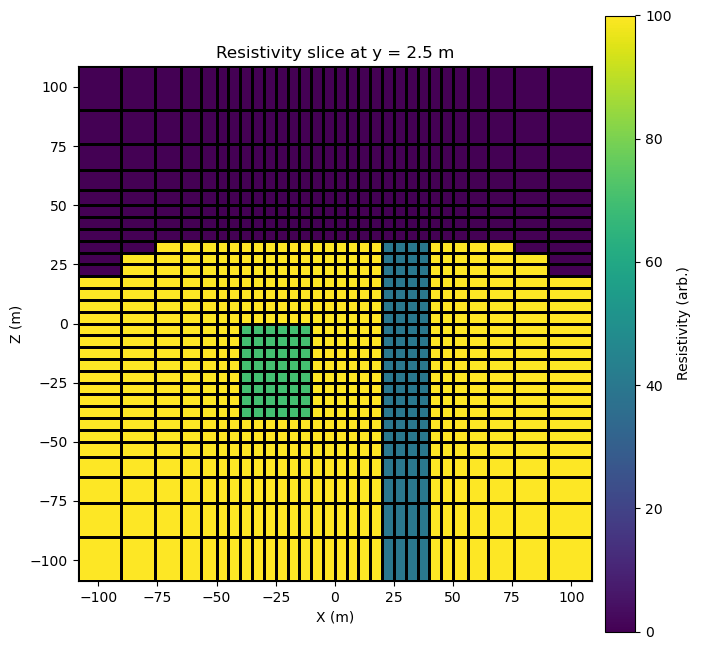

In [9]:
# Plot a central Y-slice of resistivity (ρ)
ind_slice = mesh.shape_cells[1] // 2
fig, ax = plt.subplots(figsize=(8, 8))

im = mesh.plot_slice(
    model_map * model, normal="Y", ind=ind_slice, ax=ax, grid=True,
    pcolor_opts={"cmap": plt.cm.viridis}
)

ax.set_title(f"Resistivity slice at y = {mesh.cell_centers_y[ind_slice]:.1f} m")
ax.set_xlabel("X (m)")
ax.set_ylabel("Z (m)")
ax.set_aspect("equal")
plt.colorbar(im[0], ax=ax, orientation="vertical", pad=0.02, label="Resistivity (arb.)")
plt.show()

### Models with Arbitrary Shapes

You can build models that are more complex by **starting from a background** and then **overwriting selected cells** for each shape you add. The workflow is:

1. Identify **active (subsurface) cells** from topography.
2. Initialize a model on active cells with a **background value**.
3. Get the **cell indices** for each shape (e.g., sphere, polygonal dyke).
4. Overwrite those indices with the **unit’s value**.
5. Use `InjectActiveCells` to expand the active-cells model to the **full mesh** (air filled with a constant) for plotting/simulation.


In [10]:
# Desired values for each unit (our model parameters, here resistivity)
background_value = 100.0  # Resistivity of the background
dyke_value = 40.0         # Resistivity of the dyke
sphere_value = 70.0       # Resistivity of the sphere

# Surface topography as (N, 3) points
# Already defined

# Active (subsurface) cells and mapping to full mesh
ind_active = active_from_xyz(mesh, topo)                         # Identify active cells below the topography
model_map = maps.InjectActiveCells(mesh, ind_active, air_value)  # Map active cells to the full mesh, filling air cells

# Create a resistivity model based on active cells only
model = np.full(ind_active.sum(), background_value, dtype=float) # Initialize the model with the background resistivity

# Add a sphere
ind_sphere = model_builder.get_indices_sphere(                   # Get indices of cells within a sphere
    np.r_[-25.0, 0.0, -15.0], 20.0, mesh.gridCC                  # Sphere center at X,Y,Z= (-25, 0, -15) with radius 20 m.
)
ind_sphere = ind_sphere[ind_active]                              # Restrict sphere indices to active cells
model[ind_sphere] = sphere_value                                 # Assign sphere resistivity to the model

# Define dyke corner points
xp = np.tile([-10.0, 10.0, 45.0, 25.0], 2)                       # X-coordinates of the dyke corners
yp = np.repeat([-1000.0, 1000.0], 4)                             # Y-coordinates of the dyke corners
zp = np.tile([-120.0, -120.0, 35.0, 35.0], 2)                    # Z-coordinates of the dyke corners

# Combine X, Y, Z into a single array of dyke corner points
xyz_pts = np.c_[mkvc(xp), mkvc(yp), mkvc(zp)]     

# Add a polygonal dyke (defined by corner points)
ind_polygon = model_builder.get_indices_polygon(mesh, xyz_pts)   # Get indices of cells within the polygonal dyke
ind_polygon = ind_polygon[ind_active]                            # Restrict polygon indices to active cells
model[ind_polygon] = dyke_value                                  # Assign dyke resistivity to the model

### Plot the mesh from the model with arbitrary shapes

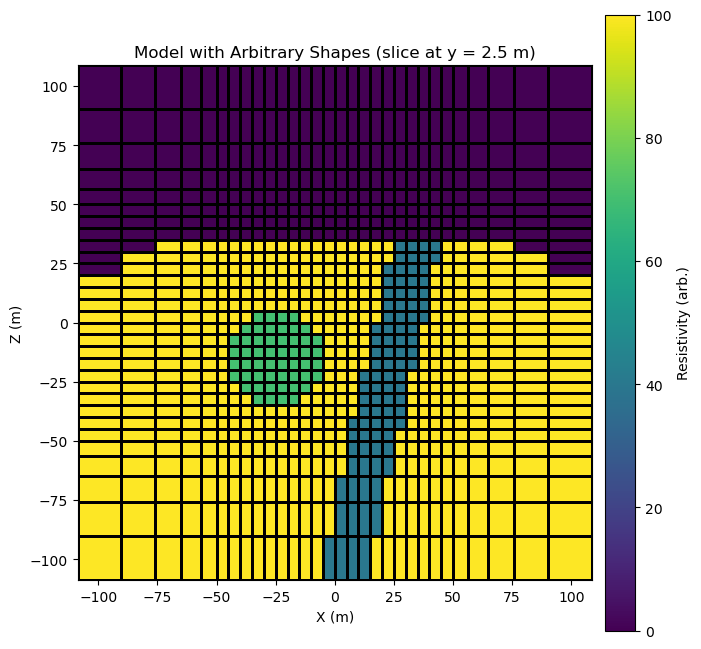

In [11]:
# Plot a central Y-slice
ind_slice = mesh.shape_cells[1] // 2
fig, ax = plt.subplots(figsize=(8, 8))

im = mesh.plot_slice(
    model_map * model, normal="Y", ind=ind_slice, ax=ax, grid=True,
    pcolor_opts={"cmap": plt.cm.viridis, "vmin": air_value, "vmax": background_value}
)

ax.set_title(f"Model with Arbitrary Shapes (slice at y = {mesh.cell_centers_y[ind_slice]:.1f} m)")
ax.set_xlabel("X (m)")
ax.set_ylabel("Z (m)")
ax.set_aspect("equal")
plt.colorbar(im[0], ax=ax, orientation="vertical", pad=0.02, label="Resistivity (arb.)")
plt.show()

### Parameterized Block Model

Rather than assigning a value to **every subsurface cell**, we can describe a body with a **small set of parameters** and let a mapping paint it onto the mesh.  

Here we use `maps.ParametricBlock` to place an **axis-aligned rectangular block** in a **half-space**:

- The **model vector** packs 8 parameters:  
  `[background, block_value, xc, dx, yc, dy, zc, dz]`
- `xc, yc, zc` are the **block center** (m); `dx, dy, dz` are the **block dimensions** (m)
- `epsilon` softens edges; `p` controls how sharp the transition is (larger → sharper)
- We still define **active cells** from topography and use `InjectActiveCells` to fill air

This is compact, fast to tweak, and great for quick “what-if” scenarios.

In [12]:
# Desired values for each unit (our model parameters, here resistivity)
background_value = 100.0          # half-space background
block_value      = 40.0           # block interior value

# Block geometry (center & dimensions in meters)
xc, yc, zc = -25.0, 0.0, -20.0    # block center
dx, dy, dz =  30.0, 40.0,  30.0   # block size in (X, Y, Z)

# Topography as (N, 3) points
# Already defined

# Defining active subsurface cells & air filling mesh
air_value  = 0.0
ind_active = active_from_xyz(mesh, topo)
active_map = maps.InjectActiveCells(mesh, ind_active, air_value)

# Parametric model vector (8 parameters)
# np.r is a numpy function for concatenating arrays
# the result is an array model = [background, block_value, xc, dx, yc, dy, zc, dz]
model = np.r_[background_value, block_value, xc, dx, yc, dy, zc, dz] 

# parametric_map: dictates how a parametric model is painted onto the active cells of the mesh
parametric_map = maps.ParametricBlock(
    mesh,
    active_cells=ind_active,  # Only paint below the topography
    epsilon=1e-10,            # Edge smoothing (small → crisp edges)
    p=5.0                     # Sharpness control (larger → sharper transitions)
)

# active_map: dictates how a model made of active cells (only) is expanded to the full mesh
# - It fills air cells (above the topography) with a constant value (air_value)
active_map = maps.InjectActiveCells(mesh, ind_active, air_value)

# Combine the two mappings:
# - First, parametric_map paints the block onto the active cells
# - Then, active_map fills the air cells with air_value
model_map = active_map * parametric_map  # Final mapping: full mesh with air filled


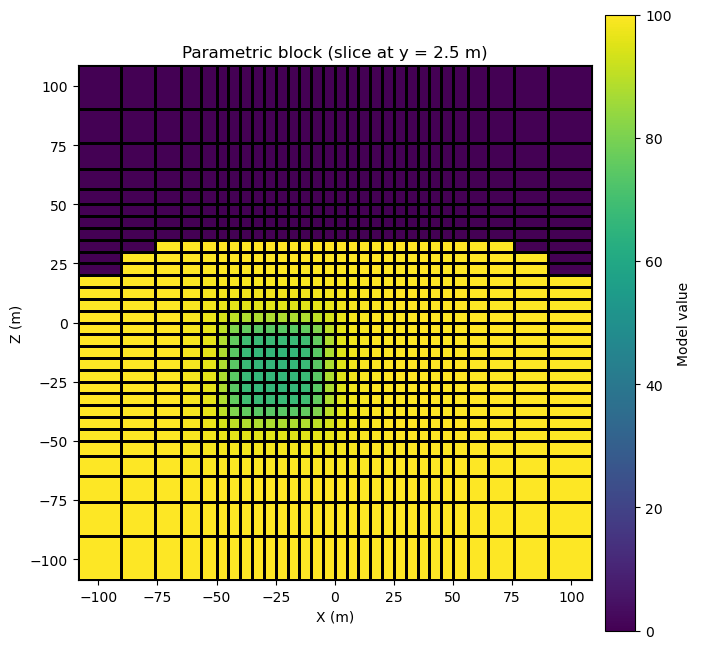

In [13]:
# Plot a central Y-slice
ind_slice = mesh.shape_cells[1] // 2
fig, ax = plt.subplots(figsize=(8, 8))

im = mesh.plot_slice(
    model_map * model,
    normal="Y",
    ind=ind_slice,
    ax=ax,
    grid=True,
    pcolor_opts={"cmap": plt.cm.viridis, "vmin": air_value, "vmax": background_value},
)

ax.set_title(f"Parametric block (slice at y = {mesh.cell_centers_y[ind_slice]:.1f} m)")
ax.set_xlabel("X (m)")
ax.set_ylabel("Z (m)")
ax.set_aspect("equal")
plt.colorbar(im[0], ax=ax, orientation="vertical", pad=0.02, label="Model value")
plt.show()

### Using Projection Maps for Multi-Parameter Models

Here, we pack **two properties** per active cell into a **single model vector** **$m$** and select each property with `maps.Projection`. Therefore, this layout is useful later when we wire each property to its own simulation in a joint inversion (e.g., send conductivity to one simulation and permeability to another).

- Model layout (with `N` active cells):
  
 $$
  \mathbf{m} \;=\; \Big[\, \underbrace{\mathbf{m}_{\log\sigma}}_{\text{length }N}\;;\; \underbrace{\mathbf{m}_{\mu}}_{\text{length }N} \,\Big]
 $$

- Projections to select each slice (total length \(2N\)):
  - `proj_log_sigma = maps.Projection(2*N, slice(0, N))` → first half (log-σ)
  - `proj_mu        = maps.Projection(2*N, slice(N, 2*N))` → second half (μ)

We then build **Combo Maps** with various **mapping chains** so each property is manipulated to the desired value to be displayed in the mesh:

- **Conductivity**:  
  `sigma_map = InjectActiveCells * ExpMap * proj_log_sigma`  
  *(right-to-left: take log-σ → `exp` to σ → inject to full mesh, keeping air fixed)*

- **Permeability**:  
  `mu_map = InjectActiveCells * proj_mu`

This keeps **one shared model vector** for inversion while ensuring each property is **transformed and expanded correctly** for simulation and plotting.

> 💡 **Why this matters for joint inversion**  
> With projections you can “wire” each property to its **own simulation** (e.g., send σ to one physics, μ to another) while optimizing a single packed model.

In [ ]:
# Property values
background_sigma = np.log(100.0) # log-conductivity 
sphere_sigma = np.log(70.0)
dyke_sigma = np.log(40.0)
background_mu = 1.0 # relative permeability
sphere_mu = 1.25

# Identify active cells in our mesh & define how to map (single) model to mesh (air filled with constant)
air_value = 0.0
ind_active = active_from_xyz(mesh, topo)              # boolean over cells
active_map = maps.InjectActiveCells(mesh, ind_active, air_value)
N = int(ind_active.sum())                             # number of active (subsurface) cells

# Build a two-parameter model over ACTIVE cells: [log_sigma, mu]
# background
model_2vars = np.tile([background_sigma, background_mu], (N, 1))

# add a conductive & permeable sphere to the background model 'model_2vars'
ind_sphere = model_builder.get_indices_sphere(np.r_[-25.0, 0.0, -15.0], 20.0, mesh.gridCC)  # boolean over ALL cells of 'mesh'
ind_sphere = ind_sphere[ind_active]                     # align with active-cell ordering
model_2vars[ind_sphere, :] = [sphere_sigma, sphere_mu]        # (log_sigma, mu)

# add a conductive, non-permeable dyke (polygon)
xp = np.kron(np.ones((2)), [-10.0, 10.0, 45.0, 25.0])
yp = np.kron([-1000.0, 1000.0], np.ones((4)))
zp = np.kron(np.ones((2)), [-120.0, -120.0, 35.0, 35.0])
xyz_pts = np.c_[xp, yp, zp]
ind_polygon = model_builder.get_indices_polygon(mesh, xyz_pts)  # boolean over ALL cells of 'mesh'
ind_polygon = ind_polygon[ind_active]                           # align with active-cell ordering
model_2vars[ind_polygon, 0] = dyke_sigma                        # for the dyke, change log_sigma only

# stack to a single 1D model vector: m = [log_sigma(active); mu(active)]
model = mkvc(model_2vars)                  # shape = (2*N,)

# Assign Projection maps for each property
proj_log_sigma = maps.Projection(2 * N, slice(0, N))        # first  N entries
proj_mu        = maps.Projection(2 * N, slice(N, 2 * N))    # second N entries

# Property-specific maps to FULL mesh
sigma_map = active_map * maps.ExpMap() * proj_log_sigma     # exp(logσ) -> σ, then inject (fill air)
mu_map    = active_map * proj_mu                            # μ already linear

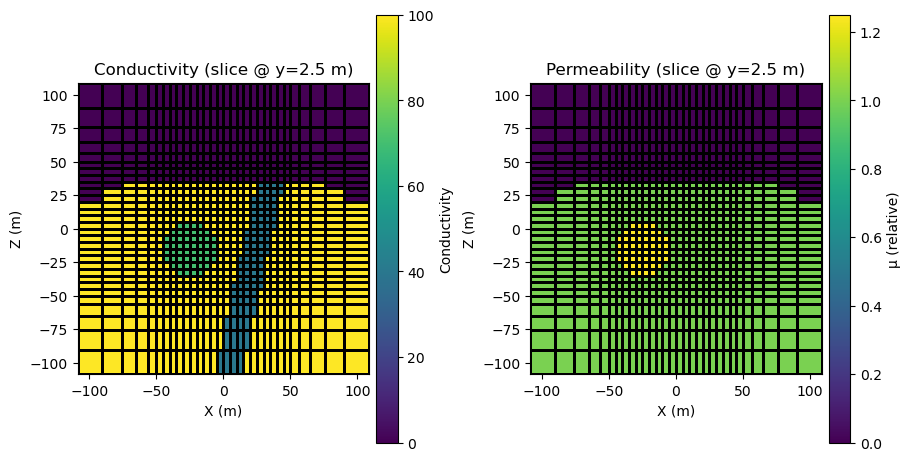

In [ ]:
# Plot central Y-slice of conductivity & permeability
ind_slice = mesh.shape_cells[1] // 2
fig, ax = plt.subplots(1, 2, figsize=(9, 4.5), constrained_layout=True)

im0 = mesh.plot_slice(sigma_map * model, normal="Y", ind=ind_slice, ax=ax[0], grid=True,
                      pcolor_opts={"cmap": "viridis"})
ax[0].set(title=f"Conductivity (slice @ y={mesh.cell_centers_y[ind_slice]:.1f} m)",
          xlabel="X (m)", ylabel="Z (m)"); ax[0].set_aspect("equal")
plt.colorbar(im0[0], ax=ax[0], orientation="vertical", pad=0.02, label="Conductivity")

im1 = mesh.plot_slice(mu_map * model, normal="Y", ind=ind_slice, ax=ax[1], grid=True,
                      pcolor_opts={"cmap": "viridis"})
ax[1].set(title=f"Permeability (slice @ y={mesh.cell_centers_y[ind_slice]:.1f} m)",
          xlabel="X (m)", ylabel="Z (m)"); ax[1].set_aspect("equal")
plt.colorbar(im1[0], ax=ax[1], orientation="vertical", pad=0.02, label="μ (relative)")

plt.show()